In [1]:
###Build a Basic Chatbot with langgraph ( Graph API functionality)

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # reducers 

In [3]:
class State(TypedDict): # the values of the state are expected to be in dictionary type
    """
    state for the chatbot : messages
    what type a state key has - here messages is a list
    how that state key shld be updated - via a function like add_messages(append) 
    """
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [9]:
from dotenv import load_dotenv, find_dotenv
import os

print("CWD:", os.getcwd())
print(".env found at:", find_dotenv())        # where python-dotenv thinks .env is
loaded = load_dotenv()
print("load_dotenv() returned:", loaded)      # True if it actually loaded some variables from .env file
print("GROQ_API_KEY value:", os.getenv("GROQ_API_KEY"))

CWD: c:\Users\nckee\OneDrive\Documents\AgenticLanggraph\1-BasicChatbot
.env found at: c:\Users\nckee\OneDrive\Documents\AgenticLanggraph\.env
load_dotenv() returned: True
GROQ_API_KEY value: 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


In [10]:
import os
from dotenv import load_dotenv

load_dotenv()


True

In [ ]:

GROQ_API_KEY = "YOUR KEY"

import os
print(os.getenv("GROQ_API_KEY") is not None)

True


In [22]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model_name="llama-3.1-8b-instant")

In [23]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F0E059A490>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F0E0598B90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [33]:
# node functionality

def chatbot(state: State):
    # Take the last message as the user input and append the LLM response
    user_input = state["messages"][-1]
    ai_response = llm.invoke(user_input)
    return {"messages": [ai_response]}  # add_messages will append this to the existing list
    # state["messages"] is the list of messages in the state; we use the last item as input to the LLM.

In [17]:
graph_builder = StateGraph(State)

#adding nodes to the graph 
graph_builder.add_node("llmchatbot", chatbot) # scond parameter is the node functionality 

#adding edges 
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph 
graph = graph_builder.compile()

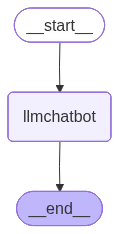

In [25]:
# to see how the graph looks like 

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [34]:
# how to run the graph 

response = graph.invoke({"messages":["Hello, how are you?"]})

In [35]:
response["messages"]


[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='1a17c669-16f1-4f3c-9edf-9af2be15ba34')]

In [36]:
# two ways of streaming the response

for event in graph.stream({"messages":["Hello, how are you?"]}):
    #print(event)
    for value in event.values():
        print(value)

None


In [32]:
# tools
from langchain_tavily import TavilySearchResults

tool = TavilySearch(max_results=2)
tool.invoke("What is the capital of France?")

ImportError: cannot import name 'TavilySearchResults' from 'langchain_tavily' (c:\Users\nckee\OneDrive\Documents\AgenticLanggraph\.venv\Lib\site-packages\langchain_tavily\__init__.py)